To predict building energy consumption and identify periods and buildings associated with unusually high energy demand.



*   نتوقع استهلاك الكهرباء بالساعة ونحدد اوقات الذروة وانماط الاستهلاك المرتفع لمساعدة المدن على إدارة الطاقة بكفاءة



In [340]:
import kagglehub

path = kagglehub.dataset_download(
    "claytonmiller/buildingdatagenomeproject2"
)

print(path)

Using Colab cache for faster access to the 'buildingdatagenomeproject2' dataset.
/kaggle/input/buildingdatagenomeproject2


In [341]:
import pandas as pd
import os
import numpy as np


electricity = pd.read_csv(
    os.path.join(path, "electricity_cleaned.csv")
)

metadata = pd.read_csv(
    os.path.join(path, "metadata.csv")
)

weather = pd.read_csv(
    os.path.join(path, "weather.csv")
)

print("Electricity:", electricity.shape)
print("Metadata:", metadata.shape)
print("Weather:", weather.shape)

Electricity: (17544, 1579)
Metadata: (1636, 32)
Weather: (331166, 10)


In [342]:
electricity.head()

,timestamp,Panther_parking_Lorriane,Panther_lodging_Cora,Panther_office_Hannah,Panther_lodging_Hattie,Panther_education_Teofila,Panther_education_Jerome,Panther_retail_Felix,Panther_parking_Asia,Panther_education_Misty,...,Cockatoo_public_Caleb,Cockatoo_education_Tyler,Cockatoo_public_Shad,Mouse_health_Buddy,Mouse_health_Modesto,Mouse_lodging_Vicente,Mouse_health_Justin,Mouse_health_Ileana,Mouse_health_Estela,Mouse_science_Micheal
0,2016-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,123.200,727.575,69.200,8.8224,370.0870,10.0,282.9965,26.0,135.0,168.2243
1,2016-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,126.475,731.200,66.275,17.6449,737.8260,30.0,574.9265,51.0,265.0,336.4486
2,2016-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,127.825,724.675,64.675,17.6449,729.9255,30.0,570.2780,50.0,272.0,336.4486
3,2016-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,130.475,737.375,65.875,17.6449,722.2620,20.0,561.1470,52.0,276.0,336.4486
4,2016-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,129.675,721.150,66.275,17.6449,719.1665,30.0,564.3695,50.0,280.0,336.4486


In [343]:
metadata.head()

,building_id,site_id,building_id_kaggle,site_id_kaggle,primaryspaceusage,sub_primaryspaceusage,sqm,sqft,lat,lng,...,yearbuilt,date_opened,numberoffloors,occupants,energystarscore,eui,site_eui,source_eui,leed_level,rating
0,Panther_lodging_Dean,Panther,NaN,0.0,Lodging/residential,Residence Hall,508.8,5477.0,28.517689,-81.379039,...,1989.0,NaN,NaN,NaN,NaN,271,NaN,NaN,NaN,NaN
1,Panther_lodging_Shelia,Panther,NaN,0.0,Lodging/residential,Residence Hall,929.0,10000.0,28.517689,-81.379039,...,1992.0,NaN,NaN,NaN,NaN,62,NaN,NaN,NaN,NaN
2,Panther_lodging_Ricky,Panther,NaN,0.0,Lodging/residential,Residence Hall,483.1,5200.0,28.517689,-81.379039,...,2016.0,NaN,NaN,NaN,NaN,534,NaN,NaN,NaN,NaN
3,Panther_education_Rosalie,Panther,0.0,0.0,Education,Research,690.5,7432.0,28.517689,-81.379039,...,2008.0,NaN,NaN,NaN,NaN,276,NaN,NaN,NaN,NaN
4,Panther_education_Misty,Panther,1.0,0.0,Education,Research,252.7,2720.0,28.517689,-81.379039,...,2004.0,NaN,NaN,NaN,NaN,375,NaN,NaN,NaN,NaN


In [344]:
weather.head()

,timestamp,site_id,airTemperature,cloudCoverage,dewTemperature,precipDepth1HR,precipDepth6HR,seaLvlPressure,windDirection,windSpeed
0,2016-01-01 00:00:00,Panther,19.4,NaN,19.4,0.0,NaN,NaN,0.0,0.0
1,2016-01-01 01:00:00,Panther,21.1,6.0,21.1,-1.0,NaN,1019.4,0.0,0.0
2,2016-01-01 02:00:00,Panther,21.1,NaN,21.1,0.0,NaN,1018.8,210.0,1.5
3,2016-01-01 03:00:00,Panther,20.6,NaN,20.0,0.0,NaN,1018.1,0.0,0.0
4,2016-01-01 04:00:00,Panther,21.1,NaN,20.6,0.0,NaN,1019.0,290.0,1.5


In [345]:
print("Electricity first columns:")
print(electricity.columns[:10].tolist())

print("Metadata columns:")
print(metadata.columns.tolist())





print("Weather columns:")
print(weather.columns.tolist())

Electricity first columns:
['timestamp', 'Panther_parking_Lorriane', 'Panther_lodging_Cora', 'Panther_office_Hannah', 'Panther_lodging_Hattie', 'Panther_education_Teofila', 'Panther_education_Jerome', 'Panther_retail_Felix', 'Panther_parking_Asia', 'Panther_education_Misty']
Metadata columns:
['building_id', 'site_id', 'building_id_kaggle', 'site_id_kaggle', 'primaryspaceusage', 'sub_primaryspaceusage', 'sqm', 'sqft', 'lat', 'lng', 'timezone', 'electricity', 'hotwater', 'chilledwater', 'steam', 'water', 'irrigation', 'solar', 'gas', 'industry', 'subindustry', 'heatingtype', 'yearbuilt', 'date_opened', 'numberoffloors', 'occupants', 'energystarscore', 'eui', 'site_eui', 'source_eui', 'leed_level', 'rating']
Weather columns:
['timestamp', 'site_id', 'airTemperature', 'cloudCoverage', 'dewTemperature', 'precipDepth1HR', 'precipDepth6HR', 'seaLvlPressure', 'windDirection', 'windSpeed']


In [346]:
#check duplicates

In [347]:
print(electricity.duplicated().sum())

0


In [348]:
print(metadata.duplicated().sum())

0


In [349]:
print(weather.duplicated().sum())

0


In [350]:
#check nulls

In [351]:
print(electricity.isna().sum().sum())

2471853


In [352]:
print(metadata.isna().sum().sum())

28173


In [353]:
print(weather.isna().sum().sum())

652836


### Select Buildings with Enough Data

Some buildings have many missing electricity readings, and this may affect the analysis and the model. First, I calculate how much data is available for each building. Then I keep buildings that have at least 90% of their readings.

I also keep only the building information that may help in predicting electricity consumption, such as the building location, use, area and year built.

In [354]:
coverage = electricity.drop(columns="timestamp").notna().mean() #نسبة البيانات المتوفرة لكل مبنى
good_buildings = coverage[coverage >= 0.90].index #here we only select good buildings

metadata_small = metadata[["building_id","site_id","primaryspaceusage","sqm","yearbuilt"]].copy()
metadata_small = metadata_small[metadata_small["building_id"].isin(good_buildings)]
metadata_small = metadata_small.dropna(subset=["site_id","primaryspaceusage","sqm"])

print("Suitable buildings:", metadata_small.shape[0])
metadata_small.head()

Suitable buildings: 1256


,building_id,site_id,primaryspaceusage,sqm,yearbuilt
136,Robin_education_Kiera,Robin,Education,4703.0,NaN
137,Robin_education_Della,Robin,Education,499.3,NaN
138,Robin_education_Lashandra,Robin,Education,9061.0,2005.0
139,Robin_education_Megan,Robin,Education,7579.0,1913.0
140,Robin_education_Mercedes,Robin,Education,5295.0,1953.0


In [355]:
# aafter filtering, the remaining buildings have enough electricity readings and
# the main building information needed for the analysis


In [356]:
# 1,256 suitable buildings! a good numbers but the rows will be huge If I use all of them,
# and the notebook may be slow and running slowly

# I will select 100 buildings randomly

In [357]:
selected_buildings = metadata_small.sample(n=100, random_state=42)["building_id"].tolist()

In [358]:
metadata_selected = metadata_small[metadata_small["building_id"].isin(selected_buildings)].copy()

In [359]:
print("Selected buildings:", metadata_selected.shape[0])
print("Number of sites:", metadata_selected["site_id"].nunique())
metadata_selected.head()

Selected buildings: 100
Number of sites: 14


,building_id,site_id,primaryspaceusage,sqm,yearbuilt
159,Robin_lodging_Renea,Robin,Lodging/residential,9548.0,1956.0
165,Robin_lodging_Pricilla,Robin,Lodging/residential,4607.0,1998.0
167,Robin_lodging_Armand,Robin,Lodging/residential,5246.0,1960.0
179,Robin_office_Wai,Robin,Office,16221.0,1960.0
180,Robin_office_Zelma,Robin,Office,7607.0,1960.0


In [360]:
metadata_selected["primaryspaceusage"].value_counts()

,count
primaryspaceusage,
Education,34
Office,22
Entertainment/public assembly,13
Public services,13
Lodging/residential,10
Other,3
Parking,2
Warehouse/storage,1
Technology/science,1


In [361]:

#change time to datetime
electricity["timestamp"] = pd.to_datetime(electricity["timestamp"])

In [362]:
electricity_selected = electricity[["timestamp"] + selected_buildings].copy()

In [363]:
electricity_long = electricity_selected.melt(id_vars="timestamp", var_name="building_id", value_name="electricity_consumption")

In [364]:
#drop the rows that does not have any readineass of electricity
electricity_long = electricity_long.dropna(subset=["electricity_consumption"])

In [365]:
print(electricity_long.shape)
electricity_long.head()

(1713540, 3)


,timestamp,building_id,electricity_consumption
0,2016-01-01 00:00:00,Rat_office_Ramiro,26.92
1,2016-01-01 01:00:00,Rat_office_Ramiro,27.00
2,2016-01-01 02:00:00,Rat_office_Ramiro,26.92
3,2016-01-01 03:00:00,Rat_office_Ramiro,26.85
4,2016-01-01 04:00:00,Rat_office_Ramiro,26.88


In [366]:
#### now i have to merge electricity with building information
# like size of building and locations and see if they have any effects in electricity consumption

In [367]:
#merge them with building_id

energy_data = electricity_long.merge(metadata_selected, on="building_id", how="left", validate="many_to_one")

In [368]:
print(energy_data.shape)
energy_data.head()

(1713540, 7)


,timestamp,building_id,electricity_consumption,site_id,primaryspaceusage,sqm,yearbuilt
0,2016-01-01 00:00:00,Rat_office_Ramiro,26.92,Rat,Office,8297.6,NaN
1,2016-01-01 01:00:00,Rat_office_Ramiro,27.00,Rat,Office,8297.6,NaN
2,2016-01-01 02:00:00,Rat_office_Ramiro,26.92,Rat,Office,8297.6,NaN
3,2016-01-01 03:00:00,Rat_office_Ramiro,26.85,Rat,Office,8297.6,NaN
4,2016-01-01 04:00:00,Rat_office_Ramiro,26.88,Rat,Office,8297.6,NaN


In [369]:
energy_data[["site_id","primaryspaceusage","sqm"]].isna().sum()

,0
site_id,0
primaryspaceusage,0
sqm,0


In [370]:
print("Before merge:", electricity_long.shape[0])
print("After merge:", energy_data.shape[0])

Before merge: 1713540
After merge: 1713540


In [371]:
###Merge the Weather Data
## to see how weather can also effect the ele consumption.. especially the temp because of cooling or heating the buildings

In [372]:
weather["timestamp"] = pd.to_datetime(weather["timestamp"])

In [373]:
weather_small = weather[["timestamp","site_id","airTemperature","cloudCoverage","dewTemperature","precipDepth1HR","seaLvlPressure","windDirection","windSpeed"]].copy()

* airTemperature: درجة الحرارة
* cloudCoverage: نسبة الغيوم
* dewTemperature: درجة الندى، لها علاقة بالرطوبة
* precipDepth1HR: كمية المطر خلال الساعة
* seaLvlPressure: الضغط الجوي
* windDirection: اتجاه الرياح
* windSpeed: سرعة الرياح



In [374]:
selected_sites = metadata_selected["site_id"].unique() ## bring the locations without repetition
weather_small = weather_small[weather_small["site_id"].isin(selected_sites)]

In [375]:
print(weather_small.duplicated(subset=["site_id","timestamp"]).sum())
print( len(selected_sites))
print( weather_small["site_id"].nunique())

0
14
14


In [376]:
final_data = energy_data.merge(weather_small, on=["site_id","timestamp"], how="left", validate="many_to_one")

In [377]:
print("Before weather merge:", energy_data.shape)
print("After weather merge:", final_data.shape)
final_data.head()

Before weather merge: (1713540, 7)
After weather merge: (1713540, 14)


,timestamp,building_id,electricity_consumption,site_id,primaryspaceusage,sqm,yearbuilt,airTemperature,cloudCoverage,dewTemperature,precipDepth1HR,seaLvlPressure,windDirection,windSpeed
0,2016-01-01 00:00:00,Rat_office_Ramiro,26.92,Rat,Office,8297.6,NaN,7.2,NaN,0.0,0.0,1021.5,350.0,5.1
1,2016-01-01 01:00:00,Rat_office_Ramiro,27.00,Rat,Office,8297.6,NaN,6.7,8.0,0.0,0.0,1021.1,340.0,3.6
2,2016-01-01 02:00:00,Rat_office_Ramiro,26.92,Rat,Office,8297.6,NaN,5.6,NaN,0.0,0.0,1020.8,350.0,3.1
3,2016-01-01 03:00:00,Rat_office_Ramiro,26.85,Rat,Office,8297.6,NaN,5.6,NaN,0.0,0.0,1021.1,340.0,3.6
4,2016-01-01 04:00:00,Rat_office_Ramiro,26.88,Rat,Office,8297.6,NaN,5.6,6.0,-1.1,0.0,1020.7,320.0,3.1


In [378]:
final_data[["airTemperature","cloudCoverage","dewTemperature","precipDepth1HR","seaLvlPressure","windDirection","windSpeed"]].isna().sum()

,0
airTemperature,6362
cloudCoverage,792633
dewTemperature,6938
precipDepth1HR,454798
seaLvlPressure,205908
windDirection,83976
windSpeed,8754


In [379]:
final_data = final_data.drop(columns=["cloudCoverage","precipDepth1HR"])

In [380]:
final_data["airTemperature"] = final_data["airTemperature"].fillna(final_data["airTemperature"].median())
final_data["dewTemperature"] = final_data["dewTemperature"].fillna(final_data["dewTemperature"].median())
final_data["seaLvlPressure"] = final_data["seaLvlPressure"].fillna(final_data["seaLvlPressure"].median())
final_data["windDirection"] = final_data["windDirection"].fillna(final_data["windDirection"].median())
final_data["windSpeed"] = final_data["windSpeed"].fillna(final_data["windSpeed"].median())

In [381]:
final_data[["airTemperature","dewTemperature","seaLvlPressure","windDirection","windSpeed"]].isna().sum()

,0
airTemperature,0
dewTemperature,0
seaLvlPressure,0
windDirection,0
windSpeed,0


In [382]:
print(final_data.shape)
final_data.head()

(1713540, 12)


,timestamp,building_id,electricity_consumption,site_id,primaryspaceusage,sqm,yearbuilt,airTemperature,dewTemperature,seaLvlPressure,windDirection,windSpeed
0,2016-01-01 00:00:00,Rat_office_Ramiro,26.92,Rat,Office,8297.6,NaN,7.2,0.0,1021.5,350.0,5.1
1,2016-01-01 01:00:00,Rat_office_Ramiro,27.00,Rat,Office,8297.6,NaN,6.7,0.0,1021.1,340.0,3.6
2,2016-01-01 02:00:00,Rat_office_Ramiro,26.92,Rat,Office,8297.6,NaN,5.6,0.0,1020.8,350.0,3.1
3,2016-01-01 03:00:00,Rat_office_Ramiro,26.85,Rat,Office,8297.6,NaN,5.6,0.0,1021.1,340.0,3.6
4,2016-01-01 04:00:00,Rat_office_Ramiro,26.88,Rat,Office,8297.6,NaN,5.6,-1.1,1020.7,320.0,3.1


In [383]:
print(final_data.isna().sum())

timestamp                       0
building_id                     0
electricity_consumption         0
site_id                         0
primaryspaceusage               0
sqm                             0
yearbuilt                  975797
airTemperature                  0
dewTemperature                  0
seaLvlPressure                  0
windDirection                   0
windSpeed                       0
dtype: int64


In [384]:
print("Buildings with missing year:", metadata_selected["yearbuilt"].isna().sum())
print("total buildings:", metadata_selected.shape[0])

Buildings with missing year: 57
total buildings: 100


In [385]:
print(metadata_selected["yearbuilt"].min())
print(metadata_selected["yearbuilt"].max())
print(metadata_selected["yearbuilt"].median())

1904.0
2014.0
1966.0


In [386]:
# yearbuilt have many missing values, so I will remove it
final_data = final_data.drop(columns=["yearbuilt"])


In [387]:
print(final_data.isna().sum())


timestamp                  0
building_id                0
electricity_consumption    0
site_id                    0
primaryspaceusage          0
sqm                        0
airTemperature             0
dewTemperature             0
seaLvlPressure             0
windDirection              0
windSpeed                  0
dtype: int64


In [388]:
print(final_data.shape)

(1713540, 11)


In [389]:
#ِEDA
# check the main numbers to understand the data
#نعرف هل فيه ارقام غريبة او قيم شاذة قبل الرسومات والمودلز
final_data[["electricity_consumption","sqm","airTemperature","dewTemperature","seaLvlPressure","windDirection","windSpeed"]].describe()

,electricity_consumption,sqm,airTemperature,dewTemperature,seaLvlPressure,windDirection,windSpeed
count,1.713540e+06,1.713540e+06,1.713540e+06,1.713540e+06,1.713540e+06,1.713540e+06,1.713540e+06
mean,1.099307e+02,6.625843e+03,1.523267e+01,7.661190e+00,1.016121e+03,1.828292e+02,3.711902e+00
std,1.546462e+02,6.078826e+03,1.034000e+01,9.675099e+00,7.220827e+00,1.079002e+02,2.329156e+00
min,1.000000e-04,3.310000e+01,-2.890000e+01,-3.500000e+01,9.682000e+02,0.000000e+00,0.000000e+00
25%,1.942250e+01,1.691000e+03,8.000000e+00,1.100000e+00,1.012200e+03,9.000000e+01,2.100000e+00
50%,6.075000e+01,4.844100e+03,1.550000e+01,8.300000e+00,1.016100e+03,1.900000e+02,3.600000e+00
75%,1.363122e+02,9.262400e+03,2.280000e+01,1.500000e+01,1.020000e+03,2.800000e+02,5.100000e+00
max,1.741000e+03,3.054280e+04,4.830000e+01,2.670000e+01,1.046500e+03,3.600000e+02,2.420000e+01


In [390]:
# notes for me to understand numbers:
# means --> 110 approx يعني متوسط استهلاك الكهرباء
#median 50%--> 60.75
# max value -->1741
#بما ان المتوسط اعلى بكثير من الوسيط فهذا يعني ان الاستهلاك مو متوزع بشكل متساوي وفيه مباني او ساعات استهلاكها مرتفع جدًا


In [391]:
# use small sample because the full data is very large
eda_sample = final_data.sample(n=100000, random_state=42)

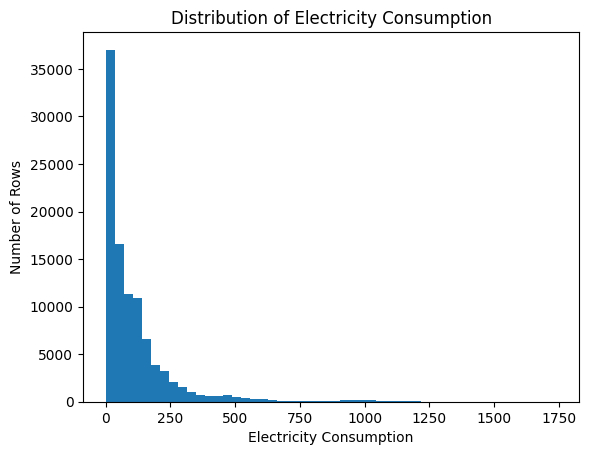

In [392]:
import matplotlib.pyplot as plt

# check how electricity values are distributed
plt.hist(eda_sample["electricity_consumption"], bins=50)
plt.xlabel("Electricity Consumption")
plt.ylabel("Number of Rows")
plt.title("Distribution of Electricity Consumption")
plt.show()

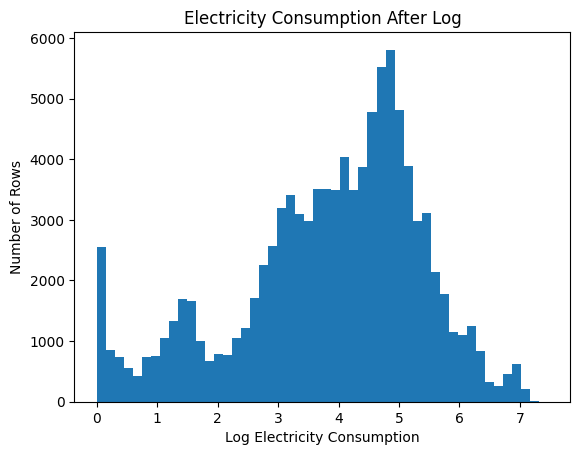

In [393]:
# log make the high values smaller so the graph is more clear

plt.hist(np.log1p(eda_sample["electricity_consumption"]), bins=50)
plt.xlabel("Log Electricity Consumption")
plt.ylabel("Number of Rows")
plt.title("Electricity Consumption After Log")
plt.show()

In [394]:
# the data is not normal because most values are low and some buildings have high use
# I will keep the high values because it can be real for large buildings

In [395]:
#check the high consumption values
final_data["electricity_consumption"].quantile([0.90,0.95,0.99])

,electricity_consumption
0.90,251.01000
0.95,391.53005
0.99,907.50610


In [396]:
# take the hour from timestamp to check the daily pattern نحتاج نعرف اوقات ذروة الطلب
final_data["hour"] = final_data["timestamp"].dt.hour

In [397]:
#avg electricity use in every hour
hour_use = final_data.groupby("hour")["electricity_consumption"].mean()

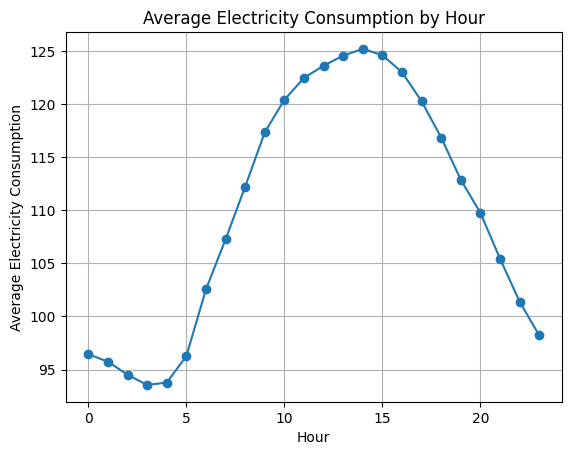

In [398]:
hour_use.plot(kind="line", marker="o")
plt.xlabel("Hour")
plt.ylabel("Average Electricity Consumption")
plt.title("Average Electricity Consumption by Hour")
plt.grid()
plt.show()

# متى يبدأ الاستهلاك يرتفع؟
# ايش ساعة الذروة؟
# متى ينخفض الاستهلاك؟
# هل يظهر فرق بين ساعات العمل والليل؟

# يبدأ يرتفع الاتسلاك بعد الساعه ٥ صباحا
#اعلى استهلاك عند ساعه ٢ الظهر
# ينخفض بعد لاساعه ٣ العصر وينزل لين الليل
#اقل استهلاك للكهربا كان بين الساعه ٢ و ٤ الفجر
#واضح انه فيه فرق بين ساعات العمل والنهار .. والاتسهلاك في النهار كان اعلى بشكل وااضح

In [399]:
# compare the average use between different building types
building_use = final_data.groupby("primaryspaceusage")["electricity_consumption"].mean().sort_values(ascending=False).head(10)

In [400]:
print("Peak hour:", hour_use.idxmax())
print("Lowest hour:", hour_use.idxmin())

Peak hour: 14
Lowest hour: 3


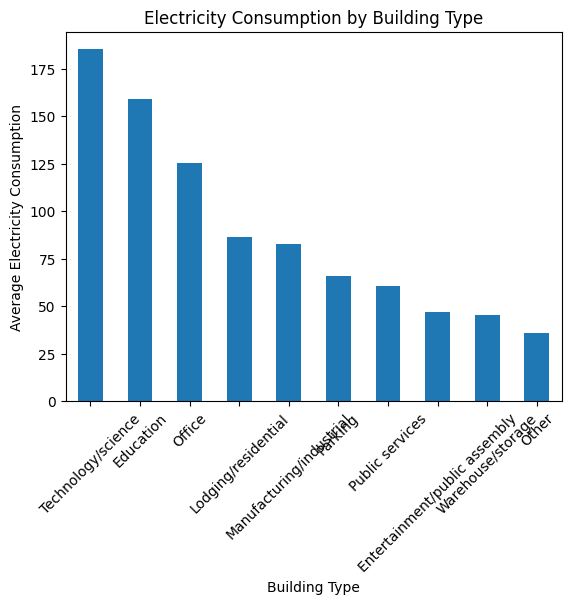

In [401]:
building_use.plot(kind="bar")
plt.xlabel("Building Type")
plt.ylabel("Average Electricity Consumption")
plt.title("Electricity Consumption by Building Type")
plt.xticks(rotation=45)
plt.show()

In [402]:
# technology and education buildings have the highest electricity use
# office buildings also have high use compared with most types
# the lowest use is in other and warehouse buildings
# وطبيعي هالشيء لان المباني الكبيره دايما تستهلك كهرباء اكثر .. بشوف كيف اذا قارنا حسب المساحه

In [403]:
#compare buildings in a more fair way based on the building size
final_data["consumption_per_sqm"] = final_data["electricity_consumption"] / final_data["sqm"]


# الافرج حسب المبنى ونوعه بالنسبه للمساحه
sqm_use = final_data.groupby("primaryspaceusage")["consumption_per_sqm"].mean().sort_values(ascending=False).head(10)

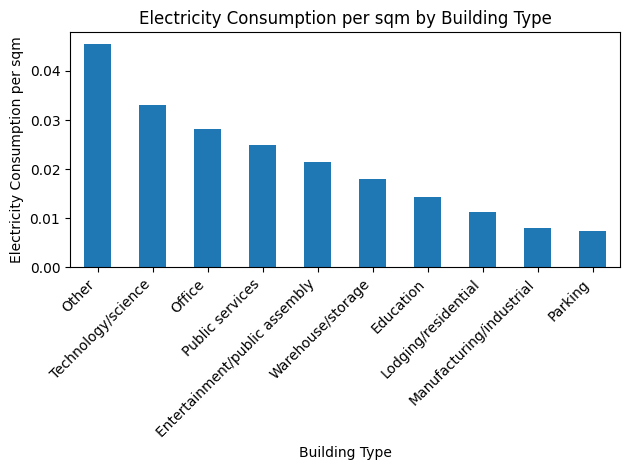

In [404]:
sqm_use.plot(kind="bar")
plt.xlabel("Building Type")
plt.ylabel("Electricity Consumption per sqm")
plt.title("Electricity Consumption per sqm by Building Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [405]:
# other buildings have the highest use per sqm
# technology and office also have high electricity use
# education was high before but it become lower after using the building size!!


In [406]:
#check how many buildings are inside every type
building_count = metadata_selected["primaryspaceusage"].value_counts()
building_count

,count
primaryspaceusage,
Education,34
Office,22
Entertainment/public assembly,13
Public services,13
Lodging/residential,10
Other,3
Parking,2
Warehouse/storage,1
Technology/science,1


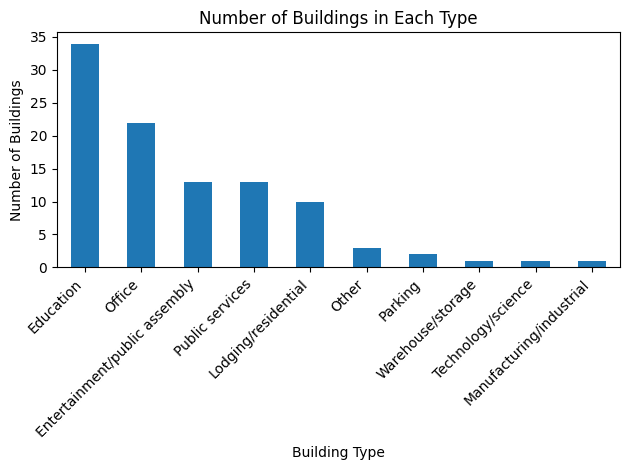

In [407]:
building_count.plot(kind="bar")
plt.xlabel("Building Type")
plt.ylabel("Number of Buildings")
plt.title("Number of Buildings in Each Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [408]:
# education and office have most buildings in the sample
# some types have only 1 or 2 buildings so their average is not very reliable

In [409]:
# check if electricity use is different in weekend
final_data["day_of_week"] = final_data["timestamp"].dt.dayofweek
final_data["is_weekend"] = final_data["day_of_week"] >= 5

week_use = final_data.groupby("is_weekend")["electricity_consumption"].mean()
week_use.index = ["Weekday","Weekend"]



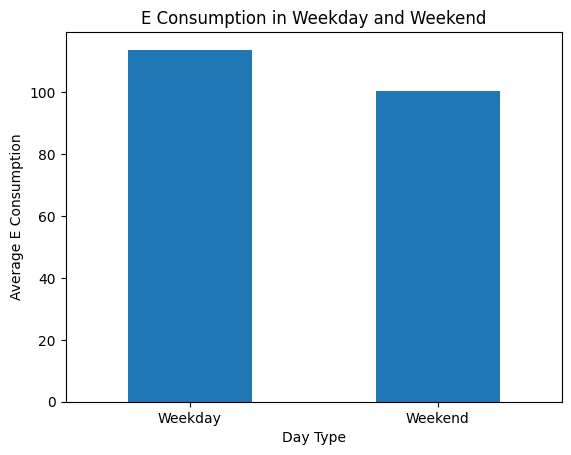

In [410]:
week_use.plot(kind="bar")
plt.xlabel("Day Type")
plt.ylabel("Average E Consumption")
plt.title("E Consumption in Weekday and Weekend")
plt.xticks(rotation=0)
plt.show()

In [411]:
# weekday have higher electricity use than weekend
# this can be because most buildings are more active in working days
print(week_use)

Weekday    113.785689
Weekend    100.374908
Name: electricity_consumption, dtype: float64


In [412]:
 # group temperature to make the relation more clear علاقة الحرارة باستهلاك الكهربا
final_data["temp_group"] = pd.cut(final_data["airTemperature"], bins=10)
temp_use = final_data.groupby("temp_group", observed=False)["electricity_consumption"].mean()

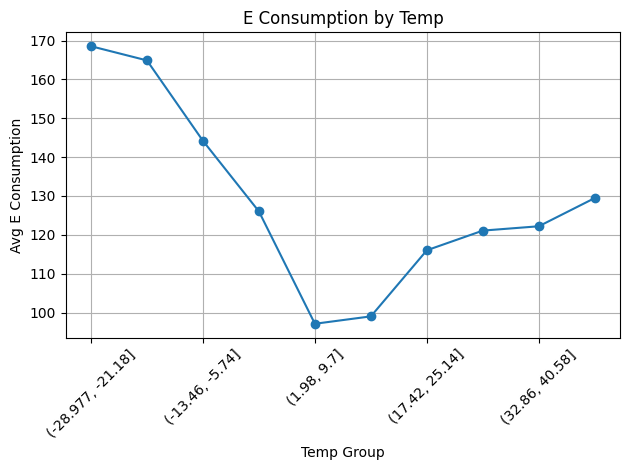

In [413]:
temp_use.plot(kind="line", marker="o")
plt.xlabel("Temp Group")
plt.ylabel("Avg E Consumption")
plt.title("E Consumption by Temp")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

In [414]:
# electricity use is high in very cold weather
# the use become lower in normal temp
# it start increasing again in hot weather, maybe because heating and cooling
####U-shaped relationship###

In [415]:
# add squared temperature because the relation is not straight
final_data["temperature_squared"] = final_data["airTemperature"] ** 2

In [416]:
#feature eng
# take time information that may affect energy use
final_data["month"] = final_data["timestamp"].dt.month
final_data["day_of_week"] = final_data["timestamp"].dt.dayofweek
final_data["is_weekend"] = (final_data["day_of_week"] >= 5).astype(int)

In [417]:
#these columns was only for EDA and not needed in the model
final_data = final_data.drop(columns=["temp_group","consumption_per_sqm"])

In [418]:
###encodings

#convert txt columns to numbers because the model only understand numbers
final_data["building_id"] = final_data["building_id"].astype("category").cat.codes
final_data["site_id"] = final_data["site_id"].astype("category").cat.codes
final_data["primaryspaceusage"] = final_data["primaryspaceusage"].astype("category").cat.codes

## استخدمت cat.codes  هنا عشان ما ابغى اضيف كولمر كثيره وهو افضل شيء لنوع المودلز اللي اخترتها

In [419]:
final_data.head()

,timestamp,building_id,electricity_consumption,site_id,primaryspaceusage,sqm,airTemperature,dewTemperature,seaLvlPressure,windDirection,windSpeed,hour,day_of_week,is_weekend,temperature_squared,month
0,2016-01-01 00:00:00,81,26.92,11,4,8297.6,7.2,0.0,1021.5,350.0,5.1,0,4,0,51.84,1
1,2016-01-01 01:00:00,81,27.00,11,4,8297.6,6.7,0.0,1021.1,340.0,3.6,1,4,0,44.89,1
2,2016-01-01 02:00:00,81,26.92,11,4,8297.6,5.6,0.0,1020.8,350.0,3.1,2,4,0,31.36,1
3,2016-01-01 03:00:00,81,26.85,11,4,8297.6,5.6,0.0,1021.1,340.0,3.6,3,4,0,31.36,1
4,2016-01-01 04:00:00,81,26.88,11,4,8297.6,5.6,-1.1,1020.7,320.0,3.1,4,4,0,31.36,1


In [420]:
final_data = final_data.drop(columns=["timestamp"])

In [421]:
final_data.dtypes

,0
building_id,int8
electricity_consumption,float64
site_id,int8
primaryspaceusage,int8
sqm,float64
airTemperature,float64
dewTemperature,float64
seaLvlPressure,float64
windDirection,float64
windSpeed,float64


In [422]:
final_data["timestamp"] = energy_data["timestamp"].values

final_data = final_data.sort_values("timestamp") # sort by time because we use old data to predict new data

In [429]:
# seperate the target from the other columns


y = final_data["electricity_consumption"]

X = final_data.drop(columns=["electricity_consumption","timestamp"])


In [430]:
#### طيب بما ان الداتا اغلبها زمنيه فالمفترض ندرب المودل على الساعات القديمه عشان مايصير اي data leakage
from sklearn.model_selection import train_test_split

#time order is important -->shuffle = false

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=False)

In [431]:
# my baseline model --> Linear Reg
# Decision Tree
#HistGradientBoosting --> better than Gradient boosting because we have huge number of rows in our dataset

In [432]:

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [433]:
#base
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)

In [434]:
X_train.dtypes

,0
building_id,int8
site_id,int8
primaryspaceusage,int8
sqm,float64
airTemperature,float64
dewTemperature,float64
seaLvlPressure,float64
windDirection,float64
windSpeed,float64
hour,int32


In [435]:
#model 2
tree_model = DecisionTreeRegressor(max_depth=15, random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

In [436]:
#model 3
boost_model = HistGradientBoostingRegressor(max_iter=100, random_state=42)
boost_model.fit(X_train, y_train)
boost_pred = boost_model.predict(X_test)

In [ ]:
## compare models by metrices

In [437]:
print("Linear Regression")
print("MAE:", round(mean_absolute_error(y_test, linear_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, linear_pred)), 2))
print("R2:", round(r2_score(y_test, linear_pred), 2))

Linear Regression
MAE: 61.84
RMSE: 105.47
R2: 0.54


In [438]:
print("Decision Tree")
print("MAE:", round(mean_absolute_error(y_test, tree_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, tree_pred)), 2))
print("R2:", round(r2_score(y_test, tree_pred), 2))

Decision Tree
MAE: 19.0
RMSE: 37.56
R2: 0.94


In [439]:
print("HistGradientBoosting")
print("MAE:", round(mean_absolute_error(y_test, boost_pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, boost_pred)), 2))
print("R2:", round(r2_score(y_test, boost_pred), 2))

HistGradientBoosting
MAE: 19.53
RMSE: 33.73
R2: 0.95


In [ ]:
# HistGradientBoosting is the best overall because it have the lowest RMSE and highest R2
# Decision Tree have slightly lower MAE, but boosting is better with large errors

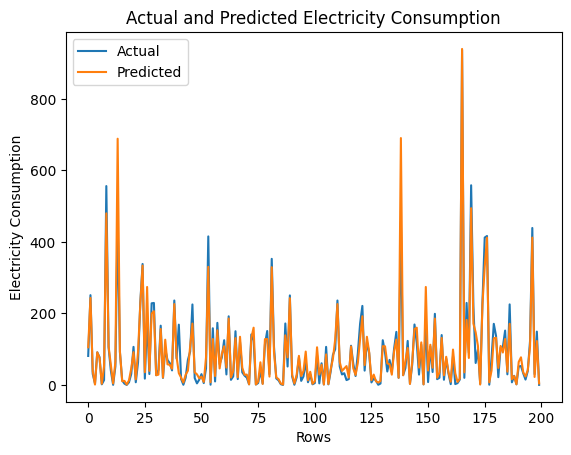

In [440]:
# compare real and predicted values for the best model
plt.plot(y_test.iloc[:200].values, label="Actual")
plt.plot(boost_pred[:200], label="Predicted")
plt.xlabel("Rows")
plt.ylabel("Electricity Consumption")
plt.title("Actual and Predicted Electricity Consumption")
plt.legend()
plt.show()

In [441]:
# select the best model
best_model = boost_model

The HistGradientBoosting model was selected as the best model with an R2 score of 0.95 and RMSE of 33.73. This shows that building information, time patterns and weather conditions can predict electricity consumption with high accuracy.